# EXPLORATORY / SUPERSEDED — energy math

This notebook is **exploratory inspection** from earlier prototypes.

**Do not use its DeployProxy / HarvestProxy / EstimatedEnergyIndex / DrivingZone-multiplier Model C as the final system.**

The design-report implementation is:

- `src/trackshift/`
- `scripts/run_energy_system.py`
- `notebooks/02_energy_system.ipynb`


In [4]:
import os
import fastf1

os.makedirs("../cache", exist_ok=True)

fastf1.Cache.enable_cache("../cache")

# EXPLORATORY / SUPERSEDED for energy math.
# Final design-report implementation: notebooks/02_energy_system.ipynb and src/trackshift/.
session = fastf1.get_session(2026, "Australian Grand Prix", "R")
session.load()

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No

In [7]:
session.laps

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 01:03:56.437000,NOR,1,0 days 00:01:36.458000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:18.163000,...,True,McLaren,0 days 01:02:19.743000,2026-03-08 04:03:26.366,1,6.0,False,,False,False
1,0 days 01:05:23.781000,NOR,1,0 days 00:01:27.344000,2.0,1.0,NaT,NaT,0 days 00:00:31.074000,0 days 00:00:18.116000,...,True,McLaren,0 days 01:03:56.437000,2026-03-08 04:05:03.060,1,6.0,False,,False,True
2,0 days 01:06:50.644000,NOR,1,0 days 00:01:26.863000,3.0,1.0,NaT,NaT,0 days 00:00:30.541000,0 days 00:00:18.252000,...,True,McLaren,0 days 01:05:23.781000,2026-03-08 04:06:30.404,1,7.0,False,,False,True
3,0 days 01:08:16.501000,NOR,1,0 days 00:01:25.857000,4.0,1.0,NaT,NaT,0 days 00:00:30.190000,0 days 00:00:18.193000,...,True,McLaren,0 days 01:06:50.644000,2026-03-08 04:07:57.267,1,7.0,False,,False,True
4,0 days 01:09:42.074000,NOR,1,0 days 00:01:25.573000,5.0,1.0,NaT,NaT,0 days 00:00:29.930000,0 days 00:00:17.868000,...,True,McLaren,0 days 01:08:16.501000,2026-03-08 04:09:23.124,1,7.0,False,,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1001,0 days 02:19:49.241000,BEA,87,0 days 00:01:24.615000,53.0,2.0,NaT,NaT,0 days 00:00:29.699000,0 days 00:00:17.937000,...,True,Haas F1 Team,0 days 02:18:24.626000,2026-03-08 05:19:31.249,1,7.0,False,,False,True
1002,0 days 02:21:13.851000,BEA,87,0 days 00:01:24.610000,54.0,2.0,NaT,NaT,0 days 00:00:29.965000,0 days 00:00:17.876000,...,True,Haas F1 Team,0 days 02:19:49.241000,2026-03-08 05:20:55.864,1,7.0,False,,False,True
1003,0 days 02:22:38.351000,BEA,87,0 days 00:01:24.500000,55.0,2.0,NaT,NaT,0 days 00:00:29.725000,0 days 00:00:17.930000,...,True,Haas F1 Team,0 days 02:21:13.851000,2026-03-08 05:22:20.474,1,7.0,False,,False,True
1004,0 days 02:24:04.790000,BEA,87,0 days 00:01:26.439000,56.0,2.0,NaT,NaT,0 days 00:00:29.768000,0 days 00:00:17.858000,...,True,Haas F1 Team,0 days 02:22:38.351000,2026-03-08 05:23:44.974,1,7.0,False,,False,True


In [8]:
session.laps.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate'],
      dtype='object')

In [9]:
session.laps.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 01:03:56.437000,NOR,1,0 days 00:01:36.458000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:18.163000,...,True,McLaren,0 days 01:02:19.743000,2026-03-08 04:03:26.366,1,6.0,False,,False,False
1,0 days 01:05:23.781000,NOR,1,0 days 00:01:27.344000,2.0,1.0,NaT,NaT,0 days 00:00:31.074000,0 days 00:00:18.116000,...,True,McLaren,0 days 01:03:56.437000,2026-03-08 04:05:03.060,1,6.0,False,,False,True
2,0 days 01:06:50.644000,NOR,1,0 days 00:01:26.863000,3.0,1.0,NaT,NaT,0 days 00:00:30.541000,0 days 00:00:18.252000,...,True,McLaren,0 days 01:05:23.781000,2026-03-08 04:06:30.404,1,7.0,False,,False,True
3,0 days 01:08:16.501000,NOR,1,0 days 00:01:25.857000,4.0,1.0,NaT,NaT,0 days 00:00:30.190000,0 days 00:00:18.193000,...,True,McLaren,0 days 01:06:50.644000,2026-03-08 04:07:57.267,1,7.0,False,,False,True
4,0 days 01:09:42.074000,NOR,1,0 days 00:01:25.573000,5.0,1.0,NaT,NaT,0 days 00:00:29.930000,0 days 00:00:17.868000,...,True,McLaren,0 days 01:08:16.501000,2026-03-08 04:09:23.124,1,7.0,False,,False,True


In [11]:
session.laps.shape

(1006, 31)

In [12]:
missing = session.laps.isna().sum()

print(missing[missing > 0].sort_values(ascending=False))

PitOutTime            974
PitInTime             973
SpeedFL                35
Sector1SessionTime     26
Sector1Time            22
LapTime                 6
Sector3SessionTime      5
Sector3Time             5
Sector2SessionTime      2
Sector2Time             2
SpeedI1                 2
SpeedI2                 2
SpeedST                 2
IsPersonalBest          2
Position                2
DeletedReason           2
dtype: int64


In [ ]:
laps = session.laps

print("=" * 70)
print("1. DATAFRAME SHAPE (rows, columns)")
print("=" * 70)
print(laps.shape)

print("\n" + "=" * 70)
print("2. ALL COLUMN NAMES")
print("=" * 70)
print(laps.columns.tolist())

print("\n" + "=" * 70)
print("3. FIRST 5 ROWS")
print("=" * 70)
print(laps.head().to_string())

print("\n" + "=" * 70)
print("4. DATA TYPES")
print("=" * 70)
print(laps.dtypes)

print("\n" + "=" * 70)
print("5. MISSING-VALUE COUNT AND PERCENTAGE (every column)")
print("=" * 70)
n_rows = len(laps)
for col in laps.columns:
    missing_count = laps[col].isna().sum()
    missing_pct = missing_count / n_rows * 100
    print(f"{col:22s}  {missing_count:5d}  ({missing_pct:6.2f}%)")

print("\n" + "=" * 70)
print("6. UNIQUE VALUES FOR IMPORTANT CATEGORICAL / FLAG COLUMNS")
print("=" * 70)
for col in ["Driver", "Compound", "Stint", "TrackStatus", "Deleted", "IsAccurate", "FreshTyre"]:
    print(f"\n--- {col} ---")
    print("n unique (including NaN if present):", laps[col].nunique(dropna=False))
    print(laps[col].value_counts(dropna=False).to_string())


In [ ]:
cols = [
    "Driver", "DriverNumber", "LapNumber", "LapTime", "Stint", "Compound",
    "PitInTime", "PitOutTime", "TrackStatus", "Position", "Deleted",
    "DeletedReason", "IsAccurate",
]

print("1. ROWS WHERE LapTime IS MISSING")
print(session.laps.loc[session.laps["LapTime"].isna(), cols].to_string())

print("\n2. ROWS WHERE Deleted == True")
print(session.laps.loc[session.laps["Deleted"] == True, cols].to_string())

print("\n3. FIRST 25 ROWS WHERE IsAccurate == False")
acc_cols = ["Driver", "LapNumber", "LapTime", "TrackStatus", "Deleted", "DeletedReason", "IsAccurate"]
print(session.laps.loc[session.laps["IsAccurate"] == False, acc_cols].head(25).to_string())

print("\n4. UNIQUE TrackStatus VALUES AND COUNTS")
print(session.laps["TrackStatus"].value_counts(dropna=False).to_string())


In [ ]:
import os

raw_cols = [
    "Driver",
    "DriverNumber",
    "Team",
    "LapNumber",
    "LapTime",
    "Position",
    "Stint",
    "Compound",
    "TyreLife",
    "FreshTyre",
    "PitInTime",
    "PitOutTime",
    "Sector1Time",
    "Sector2Time",
    "Sector3Time",
    "SpeedI1",
    "SpeedI2",
    "SpeedFL",
    "SpeedST",
    "TrackStatus",
    "Deleted",
    "DeletedReason",
    "IsAccurate",
    "FastF1Generated",
    "IsPersonalBest",
    "Time",
    "LapStartTime",
    "LapStartDate",
    "Sector1SessionTime",
    "Sector2SessionTime",
    "Sector3SessionTime",
]

laps_raw = session.laps.loc[:, raw_cols].copy()

output_dir = os.path.join("..", "data", "raw")
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "australian_gp_2026_laps_raw.csv")

print("shape:", laps_raw.shape)
print("columns:", laps_raw.columns.tolist())
print("output file path:", os.path.abspath(output_path))

laps_raw.to_csv(output_path, index=False)


In [ ]:
import os
import pandas as pd

raw_path = os.path.join("..", "data", "raw", "australian_gp_2026_laps_raw.csv")
laps = pd.read_csv(raw_path)

original_shape = laps.shape

deleted_mask = laps["Deleted"] == True
missing_laptime_mask = laps["LapTime"].isna()

n_deleted_removed = int(deleted_mask.sum())
n_missing_laptime_removed = int(missing_laptime_mask.sum())

laps_clean = laps.loc[~deleted_mask & ~missing_laptime_mask].copy()

processed_dir = os.path.join("..", "data", "processed")
os.makedirs(processed_dir, exist_ok=True)
clean_path = os.path.join(processed_dir, "australian_gp_2026_laps_clean.csv")

print("original shape:", original_shape)
print("deleted laps removed:", n_deleted_removed)
print("missing-LapTime rows removed:", n_missing_laptime_removed)
print("final shape:", laps_clean.shape)
print("remaining IsAccurate counts:")
print(laps_clean["IsAccurate"].value_counts(dropna=False).to_string())
print("remaining missing-value counts:")
print(laps_clean.isna().sum().to_string())
print("output file path:", os.path.abspath(clean_path))

laps_clean.to_csv(clean_path, index=False)


In [ ]:
import pandas as pd

clean_path = "../data/processed/australian_gp_2026_laps_clean.csv"
laps_feat = pd.read_csv(clean_path)

laps_feat["LapTimeSeconds"] = pd.to_timedelta(laps_feat["LapTime"]).dt.total_seconds()

laps_feat = laps_feat.sort_values(["Driver", "LapNumber"]).copy()

laps_feat["LapTimeDelta"] = laps_feat.groupby("Driver")["LapTimeSeconds"].diff()
laps_feat["PositionChange"] = laps_feat.groupby("Driver")["Position"].diff()

print("shape:", laps_feat.shape)

print("\nfirst 10 rows:")
print(
    laps_feat.loc[:, ["Driver", "LapNumber", "LapTimeSeconds", "LapTimeDelta", "Position", "PositionChange"]]
    .head(10)
    .to_string()
)

print("\nbasic statistics for new features:")
print(laps_feat[["LapTimeSeconds", "LapTimeDelta", "PositionChange"]].describe().to_string())
print("\nNaN counts:")
print(laps_feat[["LapTimeSeconds", "LapTimeDelta", "PositionChange"]].isna().sum().to_string())


## CHECKPOINT 1 — ORIGINAL CAR TELEMETRY INSPECTION

Extract original FastF1 car telemetry for one clean, accurate, non-pit flying lap.

- Use `lap.get_car_data(pad=1, pad_side="both")` only.
- Do not use `get_telemetry()`.
- Do not calculate DeployProxy, HarvestProxy, EstimatedEnergyIndex, or Distance.
- Do not modify the raw or cleaned CSVs.


In [ ]:
import os
import numpy as np
import pandas as pd
import fastf1

fastf1.Cache.enable_cache("../cache")
session = fastf1.get_session(2026, "Australian Grand Prix", "R")
session.load()

clean_path = os.path.join("..", "data", "processed", "australian_gp_2026_laps_clean.csv")
laps_clean = pd.read_csv(clean_path)

def is_green_flag(track_status):
    return str(track_status) == "1"

preferred = laps_clean[
    (laps_clean["Driver"] == "NOR")
    & (laps_clean["LapNumber"] == 5)
    & (laps_clean["IsAccurate"] == True)
    & laps_clean["PitInTime"].isna()
    & laps_clean["PitOutTime"].isna()
    & laps_clean["TrackStatus"].apply(is_green_flag)
]

if len(preferred) == 1:
    ref_row = preferred.iloc[0]
    selection_reason = "Preferred NOR lap 5 met all Checkpoint 1 criteria."
else:
    candidates = laps_clean[
        (laps_clean["IsAccurate"] == True)
        & laps_clean["PitInTime"].isna()
        & laps_clean["PitOutTime"].isna()
        & laps_clean["TrackStatus"].apply(is_green_flag)
    ]
    nor_candidates = candidates[candidates["Driver"] == "NOR"]
    if len(nor_candidates) > 0:
        ref_row = nor_candidates.sort_values("LapNumber").iloc[0]
        selection_reason = (
            "NOR lap 5 did not meet the criteria; "
            f"selected the earliest qualifying NOR lap instead (lap {ref_row['LapNumber']})."
        )
    else:
        ref_row = candidates.sort_values(["Driver", "LapNumber"]).iloc[0]
        selection_reason = (
            "NOR had no qualifying flying lap; "
            f"selected {ref_row['Driver']} lap {ref_row['LapNumber']} instead."
        )

print("=" * 70)
print("CHECKPOINT 1 — ORIGINAL CAR TELEMETRY INSPECTION")
print("=" * 70)
print("selection_reason:", selection_reason)

print("\nA. SELECTED REFERENCE LAP")
print("Driver:", ref_row["Driver"])
print("DriverNumber:", ref_row["DriverNumber"])
print("LapNumber:", ref_row["LapNumber"])
print("LapTime:", ref_row["LapTime"])
print("IsAccurate:", ref_row["IsAccurate"])
print("PitInTime:", ref_row["PitInTime"])
print("PitOutTime:", ref_row["PitOutTime"])
print("TrackStatus:", ref_row["TrackStatus"])

lap = session.laps.pick_drivers(str(ref_row["Driver"])).pick_laps(int(ref_row["LapNumber"])).iloc[0]
car = lap.get_car_data(pad=1, pad_side="both")

print("\nB. TELEMETRY SHAPE")
print("rows:", car.shape[0])
print("columns:", car.shape[1])

print("\nC. TELEMETRY COLUMN NAMES")
print(car.columns.tolist())

required = ["Date", "SessionTime", "Speed", "Throttle", "Brake", "Source"]
print("\nD. REQUIRED CHANNELS PRESENT?")
for col in required:
    print(f"{col}: {col in car.columns}")

print("\nE. BASIC STATISTICS")
print("\nSpeed:")
print(car["Speed"].describe().to_string())
print("\nThrottle:")
print(car["Throttle"].describe().to_string())
print("\nBrake:")
print(car["Brake"].value_counts(dropna=False).to_string())

delta_t = car["Date"].diff().dt.total_seconds()
delta_t_valid = delta_t.dropna()
print("\nF. TIME SAMPLING (Date.diff, seconds)")
print("count (including first-sample NaN):", int(delta_t.shape[0]))
print("count (valid consecutive diffs):", int(delta_t_valid.shape[0]))
print("minimum:", float(delta_t_valid.min()) if len(delta_t_valid) else np.nan)
print("median:", float(delta_t_valid.median()) if len(delta_t_valid) else np.nan)
print("mean:", float(delta_t_valid.mean()) if len(delta_t_valid) else np.nan)
print("maximum:", float(delta_t_valid.max()) if len(delta_t_valid) else np.nan)
print("n delta_t <= 0:", int((delta_t_valid <= 0).sum()))
print("n delta_t > 1.0 seconds:", int((delta_t_valid > 1.0).sum()))

throttle = pd.to_numeric(car["Throttle"], errors="coerce")
print("\nG. THROTTLE QUALITY")
print("minimum:", throttle.min())
print("maximum:", throttle.max())
print("n values < 0:", int((throttle < 0).sum()))
print("n values > 100:", int((throttle > 100).sum()))
print("n missing/non-finite:", int((~np.isfinite(throttle)).sum()))
print("n values == 104:", int((throttle == 104).sum()))

speed = pd.to_numeric(car["Speed"], errors="coerce")
print("\nH. SPEED QUALITY")
print("minimum:", speed.min())
print("maximum:", speed.max())
print("n missing/non-finite:", int((~np.isfinite(speed)).sum()))

print("\nI. BRAKE")
print("dtype:", car["Brake"].dtype)
print("unique values:", car["Brake"].unique().tolist())
print("value counts:")
print(car["Brake"].value_counts(dropna=False).to_string())

print("\nJ. SOURCE")
print("unique values:", car["Source"].unique().tolist())
print("value counts:")
print(car["Source"].value_counts(dropna=False).to_string())

print("\nFIRST 10 TELEMETRY ROWS")
print(car.head(10).to_string())

print("\nLAST 10 TELEMETRY ROWS")
print(car.tail(10).to_string())


## CHECKPOINT 2 — DISTANCE INSPECTION

Add FastF1 `Distance` to the same original NOR lap 5 car telemetry from Checkpoint 1.

- Use `get_car_data(pad=1, pad_side="both").add_distance()`.
- Do not manually integrate speed.
- Do not calculate DeployProxy, HarvestProxy, or EstimatedEnergyIndex.
- Do not modify the raw or cleaned CSVs.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import fastf1

fastf1.Cache.enable_cache("../cache")
session = fastf1.get_session(2026, "Australian Grand Prix", "R")
session.load()

clean_path = os.path.join("..", "data", "processed", "australian_gp_2026_laps_clean.csv")
laps_clean = pd.read_csv(clean_path)

def is_green_flag(track_status):
    return str(track_status) == "1"

preferred = laps_clean[
    (laps_clean["Driver"] == "NOR")
    & (laps_clean["LapNumber"] == 5)
    & (laps_clean["IsAccurate"] == True)
    & laps_clean["PitInTime"].isna()
    & laps_clean["PitOutTime"].isna()
    & laps_clean["TrackStatus"].apply(is_green_flag)
]

if len(preferred) == 1:
    ref_row = preferred.iloc[0]
    selection_reason = "Preferred NOR lap 5 met all Checkpoint 1 criteria."
else:
    candidates = laps_clean[
        (laps_clean["IsAccurate"] == True)
        & laps_clean["PitInTime"].isna()
        & laps_clean["PitOutTime"].isna()
        & laps_clean["TrackStatus"].apply(is_green_flag)
    ]
    nor_candidates = candidates[candidates["Driver"] == "NOR"]
    if len(nor_candidates) > 0:
        ref_row = nor_candidates.sort_values("LapNumber").iloc[0]
        selection_reason = (
            "NOR lap 5 did not meet the criteria; "
            f"selected the earliest qualifying NOR lap instead (lap {ref_row['LapNumber']})."
        )
    else:
        ref_row = candidates.sort_values(["Driver", "LapNumber"]).iloc[0]
        selection_reason = (
            "NOR had no qualifying flying lap; "
            f"selected {ref_row['Driver']} lap {ref_row['LapNumber']} instead."
        )

print("=" * 70)
print("CHECKPOINT 2 — DISTANCE INSPECTION")
print("=" * 70)
print("selection_reason:", selection_reason)
print("Driver:", ref_row["Driver"])
print("DriverNumber:", ref_row["DriverNumber"])
print("LapNumber:", ref_row["LapNumber"])
print("LapTime:", ref_row["LapTime"])
print("IsAccurate:", ref_row["IsAccurate"])
print("PitInTime:", ref_row["PitInTime"])
print("PitOutTime:", ref_row["PitOutTime"])
print("TrackStatus:", ref_row["TrackStatus"])

lap = session.laps.pick_drivers(str(ref_row["Driver"])).pick_laps(int(ref_row["LapNumber"])).iloc[0]
car_data = lap.get_car_data(pad=1, pad_side="both")
shape_before = car_data.shape
cols_before = car_data.columns.tolist()

car_data = car_data.add_distance()
shape_after = car_data.shape

print("\nA. TELEMETRY SHAPE")
print("before add_distance():", shape_before)
print("after add_distance():", shape_after)

print("\nB. COLUMN NAMES AFTER add_distance()")
print(car_data.columns.tolist())
print("Distance column present:", "Distance" in car_data.columns)

distance = pd.to_numeric(car_data["Distance"], errors="coerce")
print("\nC. DISTANCE")
print("dtype:", car_data["Distance"].dtype)
print("minimum:", float(distance.min()))
print("maximum:", float(distance.max()))
print("n missing:", int(distance.isna().sum()))
print("n non-finite:", int((~np.isfinite(distance)).sum()))
print("first 10 Distance values:")
print(distance.head(10).to_string())
print("last 10 Distance values:")
print(distance.tail(10).to_string())

dist_diff = distance.diff()
dist_diff_valid = dist_diff.dropna()
print("\nD. CONSECUTIVE DISTANCE DIFFERENCES")
print("count (valid diffs):", int(dist_diff_valid.shape[0]))
print("minimum difference:", float(dist_diff_valid.min()))
print("maximum difference:", float(dist_diff_valid.max()))
print("n negative differences:", int((dist_diff_valid < 0).sum()))
print("n zero differences:", int((dist_diff_valid == 0).sum()))
print("n positive differences:", int((dist_diff_valid > 0).sum()))

print("\nE. CIRCUIT / LAP DISTANCE COMPARISON")
print("final Distance (m):", float(distance.iloc[-1]))
print("max Distance (m):", float(distance.max()))
try:
    circuit_info = session.get_circuit_info()
    print("circuit_info available:", circuit_info is not None)
    if circuit_info is not None:
        print("circuit_info attributes:", [a for a in dir(circuit_info) if not a.startswith("_")])
        if hasattr(circuit_info, "corners") and circuit_info.corners is not None:
            print("corners columns:", circuit_info.corners.columns.tolist())
            if "Distance" in circuit_info.corners.columns:
                corner_dist = pd.to_numeric(circuit_info.corners["Distance"], errors="coerce")
                print("n corners:", int(len(circuit_info.corners)))
                print("min corner Distance (m):", float(corner_dist.min()))
                print("max corner Distance (m):", float(corner_dist.max()))
                print("corner Number + Distance:")
                print(circuit_info.corners[["Number", "Distance"]].to_string(index=False))
except Exception as exc:
    print("circuit_info not available or failed:", repr(exc))

print("\nF. FIRST 10 ROWS (Date, Time, SessionTime, Distance, Speed, Throttle, Brake)")
print(
    car_data.loc[:, ["Date", "Time", "SessionTime", "Distance", "Speed", "Throttle", "Brake"]]
    .head(10)
    .to_string()
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(car_data["Distance"], car_data["Speed"])
ax.set_xlabel("Distance (m)")
ax.set_ylabel("Speed (km/h)")
ax.set_title("Checkpoint 2 — NOR lap 5: Distance vs Speed (no energy calculation)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## CHECKPOINT 3 — ACCELERATION / DECELERATION INSPECTION

Derive longitudinal acceleration from original NOR lap 5 car telemetry using Speed and actual `Date` timestamps.

- Use `SpeedMS.diff() / DeltaTimeSeconds`.
- Do not assume a fixed 0.24 s interval.
- Do not calculate DeployProxy, HarvestProxy, or EstimatedEnergyIndex.
- Do not interpret deceleration as harvested energy.
- Do not modify the raw or cleaned CSVs.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import fastf1

fastf1.Cache.enable_cache("../cache")
session = fastf1.get_session(2026, "Australian Grand Prix", "R")
session.load()

clean_path = os.path.join("..", "data", "processed", "australian_gp_2026_laps_clean.csv")
laps_clean = pd.read_csv(clean_path)

def is_green_flag(track_status):
    return str(track_status) == "1"

preferred = laps_clean[
    (laps_clean["Driver"] == "NOR")
    & (laps_clean["LapNumber"] == 5)
    & (laps_clean["IsAccurate"] == True)
    & laps_clean["PitInTime"].isna()
    & laps_clean["PitOutTime"].isna()
    & laps_clean["TrackStatus"].apply(is_green_flag)
]

if len(preferred) == 1:
    ref_row = preferred.iloc[0]
    selection_reason = "Preferred NOR lap 5 met all Checkpoint 1 criteria."
else:
    candidates = laps_clean[
        (laps_clean["IsAccurate"] == True)
        & laps_clean["PitInTime"].isna()
        & laps_clean["PitOutTime"].isna()
        & laps_clean["TrackStatus"].apply(is_green_flag)
    ]
    nor_candidates = candidates[candidates["Driver"] == "NOR"]
    if len(nor_candidates) > 0:
        ref_row = nor_candidates.sort_values("LapNumber").iloc[0]
        selection_reason = (
            "NOR lap 5 did not meet the criteria; "
            f"selected the earliest qualifying NOR lap instead (lap {ref_row['LapNumber']})."
        )
    else:
        ref_row = candidates.sort_values(["Driver", "LapNumber"]).iloc[0]
        selection_reason = (
            "NOR had no qualifying flying lap; "
            f"selected {ref_row['Driver']} lap {ref_row['LapNumber']} instead."
        )

print("=" * 70)
print("CHECKPOINT 3 — ACCELERATION / DECELERATION INSPECTION")
print("=" * 70)
print("selection_reason:", selection_reason)
print("Driver:", ref_row["Driver"])
print("DriverNumber:", ref_row["DriverNumber"])
print("LapNumber:", ref_row["LapNumber"])
print("LapTime:", ref_row["LapTime"])
print("IsAccurate:", ref_row["IsAccurate"])
print("PitInTime:", ref_row["PitInTime"])
print("PitOutTime:", ref_row["PitOutTime"])
print("TrackStatus:", ref_row["TrackStatus"])

lap = session.laps.pick_drivers(str(ref_row["Driver"])).pick_laps(int(ref_row["LapNumber"])).iloc[0]
car_data = lap.get_car_data(pad=1, pad_side="both")
car_data = car_data.add_distance()

tel = car_data.copy()

tel["DeltaTimeSeconds"] = tel["Date"].diff().dt.total_seconds()
tel["SpeedMS"] = tel["Speed"] / 3.6

valid_dt = np.isfinite(tel["DeltaTimeSeconds"]) & (tel["DeltaTimeSeconds"] > 0)
n_invalid_dt = int((~valid_dt).sum())

tel["AccelerationMS2"] = tel["SpeedMS"].diff() / tel["DeltaTimeSeconds"]
tel.loc[~valid_dt, "AccelerationMS2"] = np.nan

tel["DecelerationMS2"] = np.where(
    tel["AccelerationMS2"].isna(),
    np.nan,
    np.where(tel["AccelerationMS2"] < 0, -tel["AccelerationMS2"], 0.0),
)

print("\nA. NUMBER OF TELEMETRY SAMPLES")
print("n samples:", int(len(tel)))
print("n invalid DeltaTimeSeconds (set accel/decel to NaN, rows kept):", n_invalid_dt)

print("\nB. VALID DeltaTimeSeconds")
print("n valid DeltaTimeSeconds:", int(valid_dt.sum()))

dt = tel["DeltaTimeSeconds"]
print("\nC. DeltaTimeSeconds")
print("minimum:", float(dt.min()) if dt.notna().any() else np.nan)
print("median:", float(dt.median()) if dt.notna().any() else np.nan)
print("mean:", float(dt.mean()) if dt.notna().any() else np.nan)
print("maximum:", float(dt.max()) if dt.notna().any() else np.nan)
print("n <= 0:", int((dt <= 0).sum()))
print("n non-finite:", int((~np.isfinite(dt)).sum()))

speed_ms = pd.to_numeric(tel["SpeedMS"], errors="coerce")
print("\nD. SpeedMS")
print("minimum:", float(speed_ms.min()))
print("maximum:", float(speed_ms.max()))
print("n missing/non-finite:", int((~np.isfinite(speed_ms)).sum()))

acc = pd.to_numeric(tel["AccelerationMS2"], errors="coerce")
print("\nE. AccelerationMS2")
print("minimum:", float(acc.min()) if acc.notna().any() else np.nan)
print("maximum:", float(acc.max()) if acc.notna().any() else np.nan)
print("median:", float(acc.median()) if acc.notna().any() else np.nan)
print("mean:", float(acc.mean()) if acc.notna().any() else np.nan)
print("n missing:", int(acc.isna().sum()))

dec = pd.to_numeric(tel["DecelerationMS2"], errors="coerce")
print("\nF. DecelerationMS2")
print("minimum:", float(dec.min()) if dec.notna().any() else np.nan)
print("maximum:", float(dec.max()) if dec.notna().any() else np.nan)
print("median:", float(dec.median()) if dec.notna().any() else np.nan)
print("mean:", float(dec.mean()) if dec.notna().any() else np.nan)
print("n samples where deceleration > 0:", int((dec > 0).sum()))

inspect_cols = [
    "Date",
    "DeltaTimeSeconds",
    "Speed",
    "SpeedMS",
    "AccelerationMS2",
    "DecelerationMS2",
    "Throttle",
    "Brake",
    "Distance",
]

print("\nFIRST 10 ROWS")
print(tel.loc[:, inspect_cols].head(10).to_string())

print("\nSAMPLE ROWS WITH SIGNIFICANT DECELERATION (DecelerationMS2 > 5)")
sig = tel.loc[tel["DecelerationMS2"] > 5, inspect_cols]
print("n such rows:", int(len(sig)))
print(sig.head(15).to_string())

print("\nTOP 10 STRONGEST DECELERATION SAMPLES")
top10 = tel.sort_values("DecelerationMS2", ascending=False).head(10)
print(
    top10.loc[:, ["Date", "Distance", "Speed", "AccelerationMS2", "DecelerationMS2", "Brake", "Throttle"]]
    .to_string()
)

brake_true = tel["Brake"] == True
brake_false = tel["Brake"] == False
dec_pos = tel["DecelerationMS2"] > 0
dec_zero = tel["DecelerationMS2"] == 0
dec_nan = tel["DecelerationMS2"].isna()

print("\nBRAKE vs DECELERATION COUNTS")
print("Brake=True AND Deceleration>0:", int((brake_true & dec_pos).sum()))
print("Brake=True AND Deceleration=0:", int((brake_true & dec_zero).sum()))
print("Brake=False AND Deceleration>0:", int((brake_false & dec_pos).sum()))
print("Brake=False AND Deceleration=0:", int((brake_false & dec_zero).sum()))
print("Deceleration NaN (not included above):", int(dec_nan.sum()))
print("Brake=True AND Deceleration NaN:", int((brake_true & dec_nan).sum()))
print("Brake=False AND Deceleration NaN:", int((brake_false & dec_nan).sum()))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(tel["Distance"], tel["AccelerationMS2"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Distance (m)")
ax.set_ylabel("Acceleration (m/s^2)")
ax.set_title("Checkpoint 3 — NOR lap 5: Distance vs AccelerationMS2 (no energy calculation)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## CHECKPOINT 4 — DEPLOY PROXY + HARVEST PROXY

First telemetry-informed energy **proxies** on NOR lap 5. These are not actual F1 electrical measurements.

**REAL OBSERVED DATA:** `Speed`, `Throttle`, `Brake`, `Date`

**DERIVED FEATURES:** `DeltaTimeSeconds`, `SpeedMS`, `AccelerationMS2`, `DecelerationMS2`

**TELEMETRY-INFORMED PROXIES:** `DeployProxy`, `HarvestProxy`

**NOT AVAILABLE FROM PUBLIC DATA:** actual ERS deployment, actual ERS harvesting, actual battery SOC, actual MGU-K electrical power

`DeployProxy` and `HarvestProxy` are model-derived indicators, not measurements of actual F1 electrical energy.

- `DeployProxy = (Speed / lap max Speed) * (Throttle / 100)` — estimated propulsion demand, not watts.
- `HarvestProxy` is non-zero only when `Brake == True` **and** `DecelerationMS2 >= 5.0` m/s². That 5.0 m/s² threshold is a **modeling choice**, not an F1 regulation.
- Do not calculate `EstimatedEnergyIndex` in this checkpoint.


core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 27)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished l

CHECKPOINT 4 — DEPLOY PROXY + HARVEST PROXY
These are telemetry-informed proxies, not actual ERS/SOC/MGU-K values.
Driver: NOR
DriverNumber: 1
LapNumber: 5.0
LapTime: 0 days 00:01:25.573000
IsAccurate: True
PitInTime: nan
PitOutTime: nan
TrackStatus: 1

MODELING CHOICE: DecelerationThreshold = 5.0 m/s^2
This is not an F1 regulation or measured MGU-K threshold.
max DecelerationMS2 on whole lap: 104.16666666666667
max DecelerationMS2 among HarvestActive samples: 37.03703703703709
n HarvestActive samples used for harvest normalization: 39

DECELERATION DISTRIBUTION (all samples, before harvest gating)
median: 0.0
90th percentile: 9.953703703703688
95th percentile: 20.347222222222193
99th percentile: 34.18807248108328
maximum: 104.16666666666667

TOP 10 DecelerationMS2 SAMPLES
        Distance  Speed  Brake  Throttle  DecelerationMS2  HarvestActive  HarvestProxy
139  2206.532500  189.0  False       0.0       104.166667          False      0.000000
53    970.170556  235.0   True       0.0  

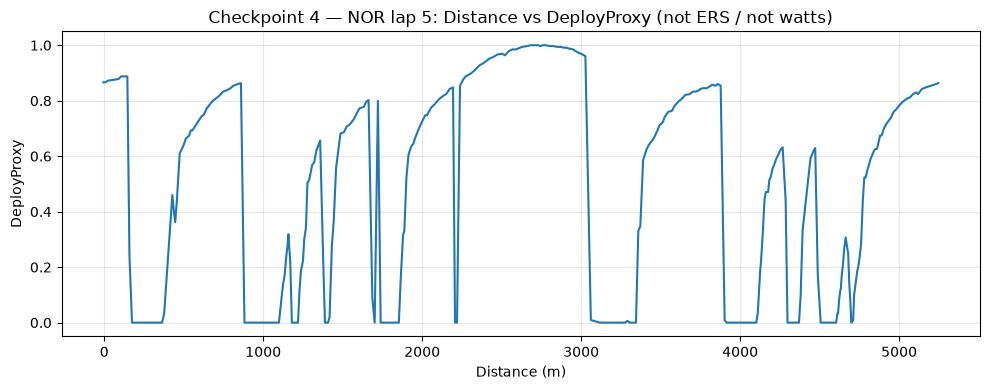

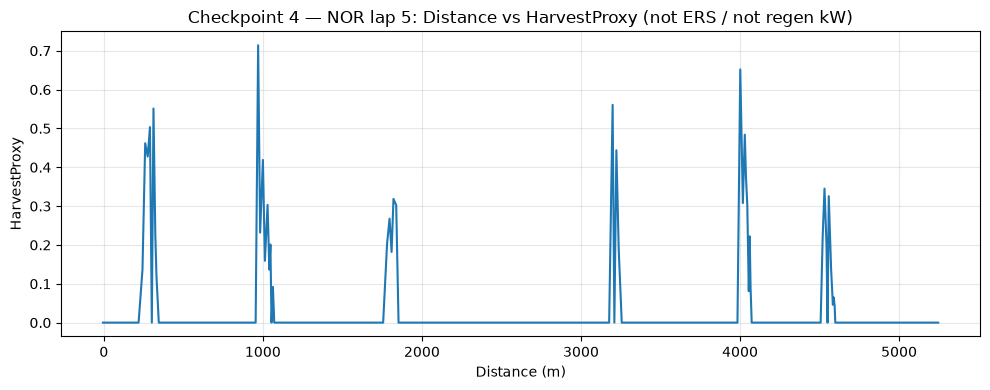

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import fastf1

fastf1.Cache.enable_cache("../cache")
session = fastf1.get_session(2026, "Australian Grand Prix", "R")
session.load()

clean_path = os.path.join("..", "data", "processed", "australian_gp_2026_laps_clean.csv")
laps_clean = pd.read_csv(clean_path)

def is_green_flag(track_status):
    return str(track_status) == "1"

preferred = laps_clean[
    (laps_clean["Driver"] == "NOR")
    & (laps_clean["LapNumber"] == 5)
    & (laps_clean["IsAccurate"] == True)
    & laps_clean["PitInTime"].isna()
    & laps_clean["PitOutTime"].isna()
    & laps_clean["TrackStatus"].apply(is_green_flag)
]
ref_row = preferred.iloc[0]

print("=" * 70)
print("CHECKPOINT 4 — DEPLOY PROXY + HARVEST PROXY")
print("=" * 70)
print("These are telemetry-informed proxies, not actual ERS/SOC/MGU-K values.")
print("Driver:", ref_row["Driver"])
print("DriverNumber:", ref_row["DriverNumber"])
print("LapNumber:", ref_row["LapNumber"])
print("LapTime:", ref_row["LapTime"])
print("IsAccurate:", ref_row["IsAccurate"])
print("PitInTime:", ref_row["PitInTime"])
print("PitOutTime:", ref_row["PitOutTime"])
print("TrackStatus:", ref_row["TrackStatus"])

lap = session.laps.pick_drivers(str(ref_row["Driver"])).pick_laps(int(ref_row["LapNumber"])).iloc[0]
car_data = lap.get_car_data(pad=1, pad_side="both").add_distance()
tel = car_data.copy()

tel["DeltaTimeSeconds"] = tel["Date"].diff().dt.total_seconds()
tel["SpeedMS"] = tel["Speed"] / 3.6
valid_dt = np.isfinite(tel["DeltaTimeSeconds"]) & (tel["DeltaTimeSeconds"] > 0)
tel["AccelerationMS2"] = tel["SpeedMS"].diff() / tel["DeltaTimeSeconds"]
tel.loc[~valid_dt, "AccelerationMS2"] = np.nan
tel["DecelerationMS2"] = np.where(
    tel["AccelerationMS2"].isna(),
    np.nan,
    np.where(tel["AccelerationMS2"] < 0, -tel["AccelerationMS2"], 0.0),
)

max_speed = float(tel["Speed"].max())
tel["SpeedNormalized"] = tel["Speed"] / max_speed
tel["ThrottleNormalized"] = tel["Throttle"] / 100.0
tel["DeployProxy"] = tel["SpeedNormalized"] * tel["ThrottleNormalized"]

DECELERATION_THRESHOLD = 5.0
print("\nMODELING CHOICE: DecelerationThreshold =", DECELERATION_THRESHOLD, "m/s^2")
print("This is not an F1 regulation or measured MGU-K threshold.")

tel["HarvestActive"] = (tel["Brake"] == True) & (tel["DecelerationMS2"] >= DECELERATION_THRESHOLD)

active_decel = tel.loc[tel["HarvestActive"], "DecelerationMS2"]
max_active_decel = float(active_decel.max()) if len(active_decel) else np.nan
print("max DecelerationMS2 on whole lap:", float(pd.to_numeric(tel["DecelerationMS2"], errors="coerce").max()))
print("max DecelerationMS2 among HarvestActive samples:", max_active_decel)
print("n HarvestActive samples used for harvest normalization:", int(len(active_decel)))

tel["DecelerationNormalized"] = np.nan
if np.isfinite(max_active_decel) and max_active_decel > 0:
    tel.loc[tel["HarvestActive"], "DecelerationNormalized"] = (
        tel.loc[tel["HarvestActive"], "DecelerationMS2"] / max_active_decel
    )

tel["HarvestProxy"] = 0.0
tel.loc[tel["HarvestActive"], "HarvestProxy"] = (
    tel.loc[tel["HarvestActive"], "SpeedNormalized"]
    * tel.loc[tel["HarvestActive"], "DecelerationNormalized"]
)

dec = pd.to_numeric(tel["DecelerationMS2"], errors="coerce")
print("\nDECELERATION DISTRIBUTION (all samples, before harvest gating)")
print("median:", float(dec.median()))
print("90th percentile:", float(np.nanpercentile(dec, 90)))
print("95th percentile:", float(np.nanpercentile(dec, 95)))
print("99th percentile:", float(np.nanpercentile(dec, 99)))
print("maximum:", float(dec.max()))

print("\nTOP 10 DecelerationMS2 SAMPLES")
print(
    tel.sort_values("DecelerationMS2", ascending=False)
    .head(10)
    .loc[:, ["Distance", "Speed", "Brake", "Throttle", "DecelerationMS2", "HarvestActive", "HarvestProxy"]]
    .to_string()
)

spike_mask = tel["DecelerationMS2"] > 50
print("\nOUTLIER CHECK (DecelerationMS2 > 50 m/s^2)")
print("n such samples:", int(spike_mask.sum()))
if spike_mask.any():
    print(tel.loc[spike_mask, ["Distance", "Speed", "Brake", "Throttle", "DecelerationMS2", "HarvestActive", "HarvestProxy"]].to_string())
    print("Does the spike enter HarvestActive?", bool(tel.loc[spike_mask, "HarvestActive"].any()))
    print("Does the spike change max_active_decel?", bool((tel.loc[spike_mask, "DecelerationMS2"] == max_active_decel).any()))

deploy = pd.to_numeric(tel["DeployProxy"], errors="coerce")
harvest = pd.to_numeric(tel["HarvestProxy"], errors="coerce")

print("\nDEPLOY PROXY")
print("minimum:", float(deploy.min()))
print("maximum:", float(deploy.max()))
print("median:", float(deploy.median()))
print("mean:", float(deploy.mean()))
print("n missing:", int(deploy.isna().sum()))
print("n zeros:", int((deploy == 0).sum()))

print("\nHARVEST PROXY")
print("minimum:", float(harvest.min()))
print("maximum:", float(harvest.max()))
print("median:", float(harvest.median()))
print("mean:", float(harvest.mean()))
print("n missing:", int(harvest.isna().sum()))
print("n non-zero:", int((harvest != 0).sum()))

print("\nSANITY CHECKS")
print("n Brake=True:", int((tel["Brake"] == True).sum()))
print("n HarvestActive=True:", int(tel["HarvestActive"].sum()))
print("n Brake=False AND DecelerationMS2>0:", int(((tel["Brake"] == False) & (tel["DecelerationMS2"] > 0)).sum()))

example_cols = [
    "Date",
    "Distance",
    "Speed",
    "Throttle",
    "Brake",
    "AccelerationMS2",
    "DecelerationMS2",
    "DeployProxy",
    "HarvestProxy",
]

print("\nFIRST 10 SAMPLES")
print(tel.loc[:, example_cols].head(10).to_string())

print("\n10 HIGHEST DeployProxy SAMPLES")
print(tel.sort_values("DeployProxy", ascending=False).head(10).loc[:, example_cols].to_string())

print("\n10 HIGHEST HarvestProxy SAMPLES")
print(tel.sort_values("HarvestProxy", ascending=False).head(10).loc[:, example_cols].to_string())

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(tel["Distance"], tel["DeployProxy"])
ax.set_xlabel("Distance (m)")
ax.set_ylabel("DeployProxy")
ax.set_title("Checkpoint 4 — NOR lap 5: Distance vs DeployProxy (not ERS / not watts)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(tel["Distance"], tel["HarvestProxy"])
ax.set_xlabel("Distance (m)")
ax.set_ylabel("HarvestProxy")
ax.set_title("Checkpoint 4 — NOR lap 5: Distance vs HarvestProxy (not ERS / not regen kW)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## CHECKPOINT 5 — SIMULATED ENERGY INDEX

Bounded, dimensionless simulated energy state on NOR lap 5.

**REAL DATA:** `Speed`, `Throttle`, `Brake`, `Date`

**DERIVED:** `DeltaTimeSeconds`, `DeployProxy`, `HarvestProxy`

**SIMULATED:** `EnergyUsed`, `EnergyRecovered`, `EstimatedEnergyIndex`

`EstimatedEnergyIndex` is a dimensionless simulated energy state. It is not actual F1 battery SOC and is not expressed in physical electrical units.

Modeling parameters (not F1 measurements):

- `InitialEnergy = 100` is an arbitrary normalized starting condition, not measured F1 battery SOC.
- `DEPLOY_RATE = 0.10` is a modeling parameter.
- `HARVEST_RATE = 0.05` is a modeling parameter.
- The state is bounded to `[0, 100]`.
- Actual public F1 battery/ERS measurements are unavailable.

Do not interpret 100 as real SOC.


core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 27)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished l

CHECKPOINT 5 — SIMULATED ENERGY INDEX
EstimatedEnergyIndex is dimensionless and simulated, not F1 battery SOC.
Driver: NOR
LapNumber: 5.0

MODEL PARAMETERS (not F1 measurements)
InitialEnergy = 100 is an arbitrary normalized starting condition, not measured F1 battery SOC.
DEPLOY_RATE: 0.1
HARVEST_RATE: 0.05

A. EnergyUsed
min: 0.0
max: 0.054528875379939216
mean: 0.011578104008647372
total: 3.8091962188449853

B. EnergyRecovered
min: 0.0
max: 0.009095744680851057
mean: 0.0004206169566060914
total: 0.13838297872340408

C. EstimatedEnergyIndex
initial value: 100.0
minimum: 96.32918675987847
maximum: 100.0
final value: 96.32918675987847
mean: 98.17880261703056
n samples at 0: 0
n samples at 100: 1
n samples < 5: 0
n samples > 95: 329

D. NET CHANGE
final - initial: -3.6708132401215323

E. TOTAL MODELED CONSUMPTION
sum(EnergyUsed): 3.8091962188449853

F. TOTAL MODELED RECOVERY
sum(EnergyRecovered): 0.13838297872340408

G. UNBOUNDED vs CLIPPED
unbounded theoretical final (initial - total us

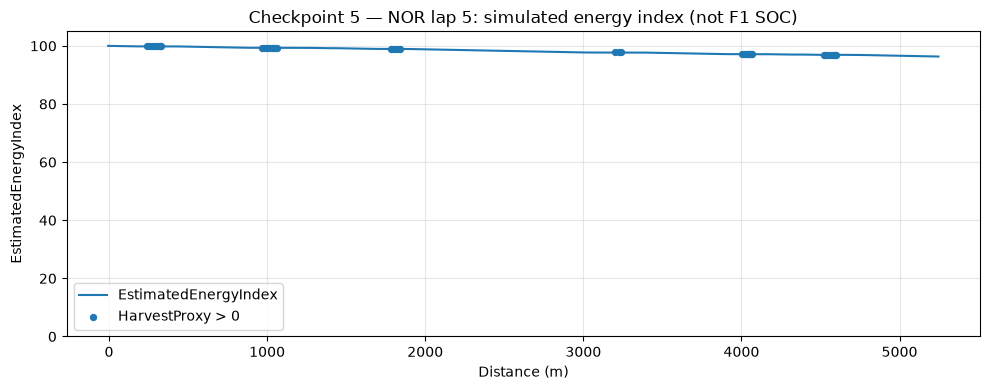

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import fastf1

fastf1.Cache.enable_cache("../cache")
session = fastf1.get_session(2026, "Australian Grand Prix", "R")
session.load()

clean_path = os.path.join("..", "data", "processed", "australian_gp_2026_laps_clean.csv")
laps_clean = pd.read_csv(clean_path)

preferred = laps_clean[
    (laps_clean["Driver"] == "NOR")
    & (laps_clean["LapNumber"] == 5)
    & (laps_clean["IsAccurate"] == True)
    & laps_clean["PitInTime"].isna()
    & laps_clean["PitOutTime"].isna()
    & (laps_clean["TrackStatus"].astype(str) == "1")
]
ref_row = preferred.iloc[0]

print("=" * 70)
print("CHECKPOINT 5 — SIMULATED ENERGY INDEX")
print("=" * 70)
print("EstimatedEnergyIndex is dimensionless and simulated, not F1 battery SOC.")
print("Driver:", ref_row["Driver"])
print("LapNumber:", ref_row["LapNumber"])

lap = session.laps.pick_drivers(str(ref_row["Driver"])).pick_laps(int(ref_row["LapNumber"])).iloc[0]
car_data = lap.get_car_data(pad=1, pad_side="both").add_distance()
tel = car_data.copy()

tel["DeltaTimeSeconds"] = tel["Date"].diff().dt.total_seconds()
tel["SpeedMS"] = tel["Speed"] / 3.6
valid_dt = np.isfinite(tel["DeltaTimeSeconds"]) & (tel["DeltaTimeSeconds"] > 0)
tel["AccelerationMS2"] = tel["SpeedMS"].diff() / tel["DeltaTimeSeconds"]
tel.loc[~valid_dt, "AccelerationMS2"] = np.nan
tel["DecelerationMS2"] = np.where(
    tel["AccelerationMS2"].isna(),
    np.nan,
    np.where(tel["AccelerationMS2"] < 0, -tel["AccelerationMS2"], 0.0),
)

max_speed = float(tel["Speed"].max())
tel["DeployProxy"] = (tel["Speed"] / max_speed) * (tel["Throttle"] / 100.0)
DECELERATION_THRESHOLD = 5.0
tel["HarvestActive"] = (tel["Brake"] == True) & (tel["DecelerationMS2"] >= DECELERATION_THRESHOLD)
active_decel = tel.loc[tel["HarvestActive"], "DecelerationMS2"]
max_active_decel = float(active_decel.max()) if len(active_decel) else np.nan
tel["HarvestProxy"] = 0.0
if np.isfinite(max_active_decel) and max_active_decel > 0:
    tel.loc[tel["HarvestActive"], "HarvestProxy"] = (
        (tel.loc[tel["HarvestActive"], "Speed"] / max_speed)
        * (tel.loc[tel["HarvestActive"], "DecelerationMS2"] / max_active_decel)
    )

INITIAL_ENERGY = 100.0
DEPLOY_RATE = 0.10
HARVEST_RATE = 0.05
print("\nMODEL PARAMETERS (not F1 measurements)")
print("InitialEnergy = 100 is an arbitrary normalized starting condition, not measured F1 battery SOC.")
print("DEPLOY_RATE:", DEPLOY_RATE)
print("HARVEST_RATE:", HARVEST_RATE)

dt = tel["DeltaTimeSeconds"].copy()
dt = dt.where(np.isfinite(dt) & (dt > 0), 0.0)

tel["EnergyUsed"] = tel["DeployProxy"].fillna(0.0) * DEPLOY_RATE * dt
tel["EnergyRecovered"] = tel["HarvestProxy"].fillna(0.0) * HARVEST_RATE * dt

n = len(tel)
energy = np.empty(n, dtype=float)
raw_after_clip_path = np.empty(n, dtype=float)
energy[0] = INITIAL_ENERGY
raw_after_clip_path[0] = INITIAL_ENERGY

for i in range(1, n):
    raw = energy[i - 1] - tel["EnergyUsed"].iloc[i] + tel["EnergyRecovered"].iloc[i]
    raw_after_clip_path[i] = raw
    energy[i] = min(100.0, max(0.0, raw))

tel["EstimatedEnergyIndex"] = energy
tel["EnergyAtFloor"] = tel["EstimatedEnergyIndex"] == 0
tel["EnergyAtCeiling"] = tel["EstimatedEnergyIndex"] == 100

used = tel["EnergyUsed"]
recovered = tel["EnergyRecovered"]
idx = tel["EstimatedEnergyIndex"]

print("\nA. EnergyUsed")
print("min:", float(used.min()))
print("max:", float(used.max()))
print("mean:", float(used.mean()))
print("total:", float(used.sum()))

print("\nB. EnergyRecovered")
print("min:", float(recovered.min()))
print("max:", float(recovered.max()))
print("mean:", float(recovered.mean()))
print("total:", float(recovered.sum()))

print("\nC. EstimatedEnergyIndex")
print("initial value:", float(idx.iloc[0]))
print("minimum:", float(idx.min()))
print("maximum:", float(idx.max()))
print("final value:", float(idx.iloc[-1]))
print("mean:", float(idx.mean()))
print("n samples at 0:", int(tel["EnergyAtFloor"].sum()))
print("n samples at 100:", int(tel["EnergyAtCeiling"].sum()))
print("n samples < 5:", int((idx < 5).sum()))
print("n samples > 95:", int((idx > 95).sum()))

print("\nD. NET CHANGE")
print("final - initial:", float(idx.iloc[-1] - idx.iloc[0]))

print("\nE. TOTAL MODELED CONSUMPTION")
print("sum(EnergyUsed):", float(used.sum()))

print("\nF. TOTAL MODELED RECOVERY")
print("sum(EnergyRecovered):", float(recovered.sum()))

unbounded_final = INITIAL_ENERGY - float(used.sum()) + float(recovered.sum())
print("\nG. UNBOUNDED vs CLIPPED")
print("unbounded theoretical final (initial - total used + total recovered):", unbounded_final)
print("actual clipped final EstimatedEnergyIndex:", float(idx.iloc[-1]))
print("n samples where raw state was < 0:", int((raw_after_clip_path < 0).sum()))
print("n samples where raw state was > 100:", int((raw_after_clip_path > 100).sum()))

example_cols = [
    "Date",
    "Distance",
    "Speed",
    "Throttle",
    "Brake",
    "DeployProxy",
    "HarvestProxy",
    "DeltaTimeSeconds",
    "EnergyUsed",
    "EnergyRecovered",
    "EstimatedEnergyIndex",
]

print("\nFIRST 10 ROWS")
print(tel.loc[:, example_cols].head(10).to_string())

print("\nHIGH DeployProxy ROWS")
print(tel.sort_values("DeployProxy", ascending=False).head(8).loc[:, example_cols].to_string())

print("\nHIGH HarvestProxy ROWS")
print(tel.sort_values("HarvestProxy", ascending=False).head(8).loc[:, example_cols].to_string())

print("\nLAST 10 ROWS")
print(tel.loc[:, example_cols].tail(10).to_string())

print("\nPARAMETER SENSITIVITY (unbounded theoretical final energy)")
deploy_mass = float((tel["DeployProxy"].fillna(0.0) * dt).sum())
harvest_mass = float((tel["HarvestProxy"].fillna(0.0) * dt).sum())
print("sum(DeployProxy * DeltaTimeSeconds):", deploy_mass)
print("sum(HarvestProxy * DeltaTimeSeconds):", harvest_mass)
for deploy_rate in (0.05, 0.10, 0.15):
    theoretical = INITIAL_ENERGY - deploy_rate * deploy_mass + 0.05 * harvest_mass
    print(f"DEPLOY_RATE={deploy_rate:.2f}, HARVEST_RATE=0.05 -> unbounded final={theoretical:.4f}")

print("\nBEHAVIOR DIAGNOSTICS")
high_deploy = tel["DeployProxy"] >= 0.8
if high_deploy.sum() > 1:
    print(
        "mean energy change on high-DeployProxy samples (index_t - index_{t-1}):",
        float(idx.diff().loc[high_deploy].mean()),
    )
harvest_on = tel["HarvestProxy"] > 0
if harvest_on.sum() > 0:
    print(
        "mean energy change on HarvestProxy>0 samples (index_t - index_{t-1}):",
        float(idx.diff().loc[harvest_on].mean()),
    )
print("max |step change| in EstimatedEnergyIndex:", float(idx.diff().abs().max()))
print("recovery smaller than deployment overall?", float(recovered.sum()) < float(used.sum()))
print("state remained in [0, 100]?", bool((idx.min() >= 0) and (idx.max() <= 100)))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(tel["Distance"], tel["EstimatedEnergyIndex"], label="EstimatedEnergyIndex")
if harvest_on.any():
    ax.scatter(
        tel.loc[harvest_on, "Distance"],
        tel.loc[harvest_on, "EstimatedEnergyIndex"],
        s=18,
        label="HarvestProxy > 0",
        zorder=3,
    )
ax.set_ylim(0, 105)
ax.set_xlabel("Distance (m)")
ax.set_ylabel("EstimatedEnergyIndex")
ax.set_title("Checkpoint 5 — NOR lap 5: simulated energy index (not F1 SOC)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## CHECKPOINT 6 — TRACK CONTEXT FROM DISTANCE

First Approach C layer: simple track location from FastF1 corner distances + telemetry `Distance`.

**Approach B:** uses vehicle telemetry to estimate deployment/recovery behaviour.

**Approach C:** adds track context so the model knows WHERE on the circuit that behaviour is occurring.

This checkpoint only builds the first track-context layer. It does **not** change `DeployProxy`, `HarvestProxy`, or `EstimatedEnergyIndex`.

**Limitation:** this does **not** identify exact braking zones. `CORNER_RADIUS_METERS = 150` is a modeling choice, not an official F1 value. It should later be checked against Brake, Deceleration, Speed, and Throttle. `CORNER_REGION` is not a braking zone.


core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 27)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished l

CHECKPOINT 6 — TRACK CONTEXT FROM DISTANCE
Driver: NOR
LapNumber: 5.0
TrackContext is geometric only. CORNER_REGION is not a braking zone.

STEP 2 — CIRCUIT INFORMATION
circuit_info type: <class 'fastf1.mvapi.data.CircuitInfo'>
attributes: ['add_marker_distance', 'corners', 'marshal_lights', 'marshal_sectors', 'rotation']
rotation: 44.0

corners columns: ['X', 'Y', 'Number', 'Letter', 'Angle', 'Distance']
n corners: 14
           X            Y  Number Letter       Angle    Distance
-3650.594482  1193.784180       1        -176.632730  353.883741
-3555.053223  1992.750244       2          -1.517007  436.700337
-7194.970215  7101.942383       3         162.258315 1082.289274
-5878.734375  7709.864746       4         -23.426263 1240.170991
-5870.662598  9676.805664       5         159.215959 1435.149386
-2280.641357 11861.559570       6          96.736266 1864.705500
-1296.382446 11398.008789       7        -104.065903 1987.203085
  502.412537 10576.311523       8          39.145642 2157

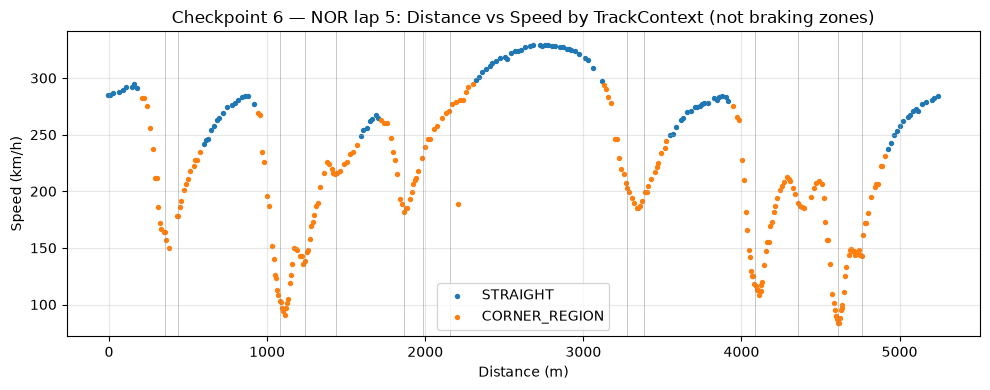

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import fastf1

fastf1.Cache.enable_cache("../cache")
session = fastf1.get_session(2026, "Australian Grand Prix", "R")
session.load()

clean_path = os.path.join("..", "data", "processed", "australian_gp_2026_laps_clean.csv")
laps_clean = pd.read_csv(clean_path)

preferred = laps_clean[
    (laps_clean["Driver"] == "NOR")
    & (laps_clean["LapNumber"] == 5)
    & (laps_clean["IsAccurate"] == True)
    & laps_clean["PitInTime"].isna()
    & laps_clean["PitOutTime"].isna()
    & (laps_clean["TrackStatus"].astype(str) == "1")
]
ref_row = preferred.iloc[0]

print("=" * 70)
print("CHECKPOINT 6 — TRACK CONTEXT FROM DISTANCE")
print("=" * 70)
print("Driver:", ref_row["Driver"])
print("LapNumber:", ref_row["LapNumber"])
print("TrackContext is geometric only. CORNER_REGION is not a braking zone.")

lap = session.laps.pick_drivers(str(ref_row["Driver"])).pick_laps(int(ref_row["LapNumber"])).iloc[0]
car_data = lap.get_car_data(pad=1, pad_side="both").add_distance()
tel = car_data.copy()

tel["DeltaTimeSeconds"] = tel["Date"].diff().dt.total_seconds()
tel["SpeedMS"] = tel["Speed"] / 3.6
valid_dt = np.isfinite(tel["DeltaTimeSeconds"]) & (tel["DeltaTimeSeconds"] > 0)
tel["AccelerationMS2"] = tel["SpeedMS"].diff() / tel["DeltaTimeSeconds"]
tel.loc[~valid_dt, "AccelerationMS2"] = np.nan
tel["DecelerationMS2"] = np.where(
    tel["AccelerationMS2"].isna(),
    np.nan,
    np.where(tel["AccelerationMS2"] < 0, -tel["AccelerationMS2"], 0.0),
)

print("\nSTEP 2 — CIRCUIT INFORMATION")
circuit_info = session.get_circuit_info()
print("circuit_info type:", type(circuit_info))
print("attributes:", [a for a in dir(circuit_info) if not a.startswith("_")])
print("rotation:", getattr(circuit_info, "rotation", None))

corners = circuit_info.corners.copy()
print("\ncorners columns:", corners.columns.tolist())
print("n corners:", int(len(corners)))
print(corners.to_string(index=False))

print("\nunique corner Number values:", corners["Number"].tolist())
if "Letter" in corners.columns:
    print("unique corner Letter values:", corners["Letter"].unique().tolist())

CORNER_RADIUS_METERS = 150
print("\nMODELING CHOICE: CORNER_RADIUS_METERS =", CORNER_RADIUS_METERS)
print("This is not an official F1 value.")

corner_dist = corners["Distance"].to_numpy(dtype=float)
corner_num = corners["Number"].to_numpy()
tel_dist = tel["Distance"].to_numpy(dtype=float)[:, None]
abs_diff = np.abs(tel_dist - corner_dist)
nearest_i = abs_diff.argmin(axis=1)

tel["NearestCorner"] = corner_num[nearest_i]
tel["DistanceToNearestCorner"] = abs_diff[np.arange(len(tel)), nearest_i]
tel["TrackContext"] = np.where(
    tel["DistanceToNearestCorner"] <= CORNER_RADIUS_METERS,
    "CORNER_REGION",
    "STRAIGHT",
)

print("\nA. n telemetry samples:", int(len(tel)))
print("\nB/C. TrackContext counts")
counts = tel["TrackContext"].value_counts()
print(counts.to_string())
print("percentages:")
print((counts / len(tel) * 100).round(2).to_string())

print("\nD. Unique FastF1 corner numbers:", corners["Number"].tolist())

print("\nE. PER-CORNER SAMPLES WITHIN RADIUS")
rows = []
for _, crow in corners.iterrows():
    cnum = crow["Number"]
    cdist = float(crow["Distance"])
    within = tel.loc[(tel["Distance"] - cdist).abs() <= CORNER_RADIUS_METERS]
    rows.append(
        {
            "corner": cnum,
            "letter": crow["Letter"] if "Letter" in crow.index else "",
            "corner_distance_m": cdist,
            "n_samples_within_radius": int(len(within)),
            "min_telemetry_Distance": float(within["Distance"].min()) if len(within) else np.nan,
            "max_telemetry_Distance": float(within["Distance"].max()) if len(within) else np.nan,
        }
    )
corner_summary = pd.DataFrame(rows)
print(corner_summary.to_string(index=False))

example_cols = [
    "Date",
    "Distance",
    "Speed",
    "Throttle",
    "Brake",
    "AccelerationMS2",
    "DecelerationMS2",
    "NearestCorner",
    "DistanceToNearestCorner",
    "TrackContext",
]

print("\nFIRST 10 ROWS")
print(tel.loc[:, example_cols].head(10).to_string())

print("\n10 ROWS NEAREST TO CORNERS")
print(tel.sort_values("DistanceToNearestCorner").head(10).loc[:, example_cols].to_string())

print("\n10 ROWS CLASSIFIED AS STRAIGHT")
straight = tel.loc[tel["TrackContext"] == "STRAIGHT", example_cols]
print(straight.head(10).to_string())

print("\nSTEP 7 — SAMPLE BEHAVIOUR NEAR SELECTED CORNERS")
for cnum in [1, 3, 9, 14]:
    near = tel.loc[tel["NearestCorner"] == cnum, example_cols]
    print(f"\n--- nearest to corner {cnum}: n={len(near)} ---")
    if len(near) == 0:
        print("no samples")
        continue
    print("Speed min/median/max:", float(near["Speed"].min()), float(near["Speed"].median()), float(near["Speed"].max()))
    print("Throttle mean:", float(near["Throttle"].mean()))
    print("Brake=True fraction:", float((near["Brake"] == True).mean()))
    print("DecelerationMS2 mean:", float(near["DecelerationMS2"].mean()))
    print("TrackContext counts:")
    print(near["TrackContext"].value_counts().to_string())
    print(near.head(8).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
straight_mask = tel["TrackContext"] == "STRAIGHT"
corner_mask = tel["TrackContext"] == "CORNER_REGION"
ax.scatter(tel.loc[straight_mask, "Distance"], tel.loc[straight_mask, "Speed"], s=8, label="STRAIGHT")
ax.scatter(tel.loc[corner_mask, "Distance"], tel.loc[corner_mask, "Speed"], s=8, label="CORNER_REGION")
for _, crow in corners.iterrows():
    ax.axvline(float(crow["Distance"]), color="gray", linewidth=0.6, alpha=0.5)
ax.set_xlabel("Distance (m)")
ax.set_ylabel("Speed (km/h)")
ax.set_title("Checkpoint 6 — NOR lap 5: Distance vs Speed by TrackContext (not braking zones)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## CHECKPOINT 7 — TELEMETRY-BASED DRIVING ZONES

**Checkpoint 6 `TrackContext`:** geometric location (WHERE is the car?).

**Checkpoint 7 `DrivingZone`:** observed vehicle behaviour (WHAT is the car doing?).

These are complementary. Keep both. Do not replace one with the other.

`DrivingZone` is a heuristic from public telemetry. It is not official F1 timing, official braking-zone data, ERS, MGU-K, or battery state.

Thresholds are modeling choices:

- `BRAKING_DECEL_THRESHOLD = 5.0` m/s²
- `ACCELERATION_THRESHOLD = 2.0` m/s²
- `LOW_SPEED_THRESHOLD = 180.0` km/h

This checkpoint does **not** feed `DrivingZone` into `DeployProxy`, `HarvestProxy`, or `EstimatedEnergyIndex`.


CHECKPOINT 7 — TELEMETRY-BASED DRIVING ZONES
Driver: NOR
LapNumber: 5.0
DrivingZone is a heuristic. Thresholds are modeling choices, not F1 rules.

MODELING CHOICES (not official F1 thresholds)
BRAKING_DECEL_THRESHOLD: 5.0 m/s^2
ACCELERATION_THRESHOLD: 2.0 m/s^2
LOW_SPEED_THRESHOLD: 180.0 km/h

FIRST-SAMPLE HANDLING
row 0 AccelerationMS2: nan
row 0 DecelerationMS2: nan
row 0 DrivingZone: CRUISE
NaN accel/decel fails the numeric comparisons, so those rules do not fire; the sample falls through.

ZONE COUNTS
DrivingZone
ACCELERATION        131
CRUISE              112
LOW_SPEED_CORNER     47
BRAKING              39
percentages:
DrivingZone
ACCELERATION        39.82
CRUISE              34.04
LOW_SPEED_CORNER    14.29
BRAKING             11.85

SANITY COUNTS
Brake=True: 50
Brake=True AND DrivingZone=BRAKING: 39
DecelerationMS2 >= 5: 60
ACCELERATION count: 131
LOW_SPEED_CORNER count: 47

DrivingZone x TrackContext
TrackContext      CORNER_REGION  STRAIGHT  All
DrivingZone                    

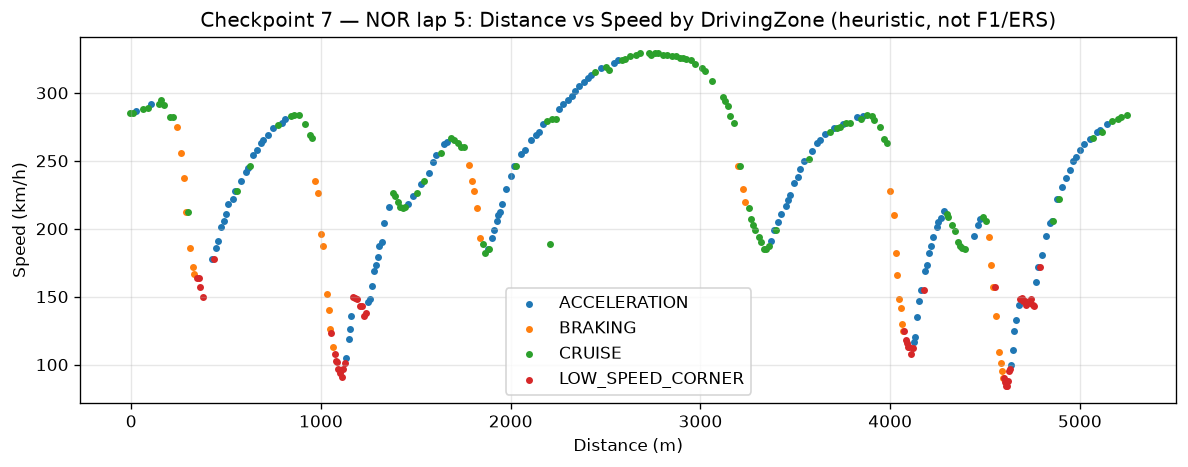

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import fastf1

fastf1.Cache.enable_cache("../cache")
session = fastf1.get_session(2026, "Australian Grand Prix", "R")
session.load()

clean_path = os.path.join("..", "data", "processed", "australian_gp_2026_laps_clean.csv")
laps_clean = pd.read_csv(clean_path)

preferred = laps_clean[
    (laps_clean["Driver"] == "NOR")
    & (laps_clean["LapNumber"] == 5)
    & (laps_clean["IsAccurate"] == True)
    & laps_clean["PitInTime"].isna()
    & laps_clean["PitOutTime"].isna()
    & (laps_clean["TrackStatus"].astype(str) == "1")
]
ref_row = preferred.iloc[0]

print("=" * 70)
print("CHECKPOINT 7 — TELEMETRY-BASED DRIVING ZONES")
print("=" * 70)
print("Driver:", ref_row["Driver"])
print("LapNumber:", ref_row["LapNumber"])
print("DrivingZone is a heuristic. Thresholds are modeling choices, not F1 rules.")

lap = session.laps.pick_drivers(str(ref_row["Driver"])).pick_laps(int(ref_row["LapNumber"])).iloc[0]
car_data = lap.get_car_data(pad=1, pad_side="both").add_distance()
tel = car_data.copy()

tel["DeltaTimeSeconds"] = tel["Date"].diff().dt.total_seconds()
tel["SpeedMS"] = tel["Speed"] / 3.6
valid_dt = np.isfinite(tel["DeltaTimeSeconds"]) & (tel["DeltaTimeSeconds"] > 0)
tel["AccelerationMS2"] = tel["SpeedMS"].diff() / tel["DeltaTimeSeconds"]
tel.loc[~valid_dt, "AccelerationMS2"] = np.nan
tel["DecelerationMS2"] = np.where(
    tel["AccelerationMS2"].isna(),
    np.nan,
    np.where(tel["AccelerationMS2"] < 0, -tel["AccelerationMS2"], 0.0),
)

CORNER_RADIUS_METERS = 150
corners = session.get_circuit_info().corners
corner_dist = corners["Distance"].to_numpy(dtype=float)
corner_num = corners["Number"].to_numpy()
abs_diff = np.abs(tel["Distance"].to_numpy(dtype=float)[:, None] - corner_dist)
nearest_i = abs_diff.argmin(axis=1)
tel["NearestCorner"] = corner_num[nearest_i]
tel["DistanceToNearestCorner"] = abs_diff[np.arange(len(tel)), nearest_i]
tel["TrackContext"] = np.where(
    tel["DistanceToNearestCorner"] <= CORNER_RADIUS_METERS,
    "CORNER_REGION",
    "STRAIGHT",
)

BRAKING_DECEL_THRESHOLD = 5.0
ACCELERATION_THRESHOLD = 2.0
LOW_SPEED_THRESHOLD = 180.0
print("\nMODELING CHOICES (not official F1 thresholds)")
print("BRAKING_DECEL_THRESHOLD:", BRAKING_DECEL_THRESHOLD, "m/s^2")
print("ACCELERATION_THRESHOLD:", ACCELERATION_THRESHOLD, "m/s^2")
print("LOW_SPEED_THRESHOLD:", LOW_SPEED_THRESHOLD, "km/h")

braking = (tel["Brake"] == True) & (tel["DecelerationMS2"] >= BRAKING_DECEL_THRESHOLD)
accel_zone = (
    (~braking)
    & (tel["AccelerationMS2"] >= ACCELERATION_THRESHOLD)
    & (tel["Throttle"] >= 50)
)
low_speed = (
    (~braking)
    & (~accel_zone)
    & (tel["Speed"] <= LOW_SPEED_THRESHOLD)
    & (tel["TrackContext"] == "CORNER_REGION")
)

tel["DrivingZone"] = "CRUISE"
tel.loc[low_speed, "DrivingZone"] = "LOW_SPEED_CORNER"
tel.loc[accel_zone, "DrivingZone"] = "ACCELERATION"
tel.loc[braking, "DrivingZone"] = "BRAKING"

print("\nFIRST-SAMPLE HANDLING")
print("row 0 AccelerationMS2:", tel.loc[0, "AccelerationMS2"])
print("row 0 DecelerationMS2:", tel.loc[0, "DecelerationMS2"])
print("row 0 DrivingZone:", tel.loc[0, "DrivingZone"])
print("NaN accel/decel fails the numeric comparisons, so those rules do not fire; the sample falls through.")

zone_counts = tel["DrivingZone"].value_counts()
print("\nZONE COUNTS")
print(zone_counts.to_string())
print("percentages:")
print((zone_counts / len(tel) * 100).round(2).to_string())

print("\nSANITY COUNTS")
print("Brake=True:", int((tel["Brake"] == True).sum()))
print("Brake=True AND DrivingZone=BRAKING:", int(((tel["Brake"] == True) & (tel["DrivingZone"] == "BRAKING")).sum()))
print("DecelerationMS2 >= 5:", int((tel["DecelerationMS2"] >= BRAKING_DECEL_THRESHOLD).sum()))
print("ACCELERATION count:", int((tel["DrivingZone"] == "ACCELERATION").sum()))
print("LOW_SPEED_CORNER count:", int((tel["DrivingZone"] == "LOW_SPEED_CORNER").sum()))

print("\nDrivingZone x TrackContext")
print(pd.crosstab(tel["DrivingZone"], tel["TrackContext"], margins=True).to_string())

print("\nBrake x DrivingZone")
print(pd.crosstab(tel["Brake"], tel["DrivingZone"], margins=True).to_string())
brake_true_not_braking = (tel["Brake"] == True) & (tel["DrivingZone"] != "BRAKING")
print("Brake=True but not BRAKING:", int(brake_true_not_braking.sum()))
if brake_true_not_braking.any():
    print("Those samples keep Brake=True but DecelerationMS2 < 5 (or NaN), so they are not forced into BRAKING.")
    print(
        tel.loc[
            brake_true_not_braking,
            ["Distance", "Speed", "Throttle", "Brake", "DecelerationMS2", "TrackContext", "DrivingZone"],
        ].to_string()
    )

print("\nZONE DESCRIPTIVE STATS")
zone_stats = tel.groupby("DrivingZone").agg(
    count=("DrivingZone", "size"),
    mean_Speed=("Speed", "mean"),
    mean_Throttle=("Throttle", "mean"),
    mean_DecelerationMS2=("DecelerationMS2", "mean"),
    mean_AccelerationMS2=("AccelerationMS2", "mean"),
    mean_DistanceToNearestCorner=("DistanceToNearestCorner", "mean"),
)
print(zone_stats.to_string())

example_cols = [
    "Date",
    "Distance",
    "Speed",
    "Throttle",
    "Brake",
    "AccelerationMS2",
    "DecelerationMS2",
    "NearestCorner",
    "DistanceToNearestCorner",
    "TrackContext",
    "DrivingZone",
]

for zone in ["BRAKING", "ACCELERATION", "CRUISE", "LOW_SPEED_CORNER"]:
    print(f"\nEXAMPLES: {zone}")
    subset = tel.loc[tel["DrivingZone"] == zone, example_cols]
    print("n=", int(len(subset)))
    print(subset.head(5).to_string())

tel["PreviousDrivingZone"] = tel["DrivingZone"].shift(1)
trans = tel.loc[tel["PreviousDrivingZone"].notna() & (tel["DrivingZone"] != tel["PreviousDrivingZone"])].copy()
print("\nTRANSITIONS")
print("n transitions:", int(len(trans)))
print(pd.crosstab(trans["PreviousDrivingZone"], trans["DrivingZone"], margins=True).to_string())
print("\nFIRST TRANSITION ROWS")
print(
    trans.loc[
        :,
        [
            "Distance",
            "Speed",
            "Throttle",
            "Brake",
            "AccelerationMS2",
            "DecelerationMS2",
            "PreviousDrivingZone",
            "DrivingZone",
        ],
    ]
    .head(15)
    .to_string()
)

fig, ax = plt.subplots(figsize=(10, 4))
for zone, subset in tel.groupby("DrivingZone"):
    ax.scatter(subset["Distance"], subset["Speed"], s=10, label=zone)
ax.set_xlabel("Distance (m)")
ax.set_ylabel("Speed (km/h)")
ax.set_title("Checkpoint 7 — NOR lap 5: Distance vs Speed by DrivingZone (heuristic, not F1/ERS)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## CHECKPOINT 8 — TRACK-AWARE ENERGY MODEL COMPARISON

This is an **experimental model comparison**, not a measurement-accuracy validation.

There is no publicly available ground-truth ERS deployment, ERS harvesting, battery SOC, or MGU-K electrical-power signal here. We therefore **cannot** say that Model C is more accurate.

**APPROACH B (telemetry-only):**

    Observable vehicle telemetry
        ↓
    DeployProxy / HarvestProxy
        ↓
    Simulated EnergyIndex (`EstimatedEnergyIndex_B`)

**APPROACH C (telemetry + track context):**

    Observable vehicle telemetry
        +
    Track location/context (`DrivingZone`)
        ↓
    Context-adjusted proxies (`DeployProxy_C` / `HarvestProxy_C`)
        ↓
    Simulated EnergyIndex (`EstimatedEnergyIndex_C`)

Approach C is **not automatically superior**. Its value must come from whether track context adds useful information beyond the raw vehicle telemetry.

Original `DeployProxy` and `HarvestProxy` formulas are unchanged. Rates stay `DEPLOY_RATE = 0.10` and `HARVEST_RATE = 0.05`.

Context multipliers are **modeling choices**, not F1 measurements:

- Acceleration is a stronger deployment context (higher propulsion demand).
- Low-speed corners generally have lower propulsion demand.
- Braking is the strongest recovery context.
- Acceleration/cruise are not treated as recovery.


CHECKPOINT 8 — TRACK-AWARE ENERGY MODEL COMPARISON
Experimental comparison only. No ground-truth SOC/ERS. Not a validation.
Driver: NOR
LapNumber: 5.0

RATES UNCHANGED FROM CHECKPOINT 5 (modeling parameters, not F1)
DEPLOY_RATE: 0.1
HARVEST_RATE: 0.05

MODEL C CONTEXT MULTIPLIERS (modeling choices, not F1 measurements)
DeploymentContextMultiplier: ACCELERATION=1.10, CRUISE=1.00, LOW_SPEED_CORNER=0.80, BRAKING=0.00
HarvestContextMultiplier:    BRAKING=1.10, LOW_SPEED_CORNER=0.50, ACCELERATION=0.00, CRUISE=0.00
Why: acceleration is stronger deployment; low-speed corners have lower propulsion demand;
braking is the strongest recovery context; acceleration/cruise are not treated as recovery.

STEP 6 — MODEL COMPARISON

MODEL B
total EnergyUsed: 3.8091962188449853
total EnergyRecovered: 0.13838297872340408
final EnergyIndex: 96.32918675987847
minimum EnergyIndex: 96.32918675987847
maximum EnergyIndex: 100.0

MODEL C
total EnergyUsed: 4.022049709422493
total EnergyRecovered: 0.15222127659574

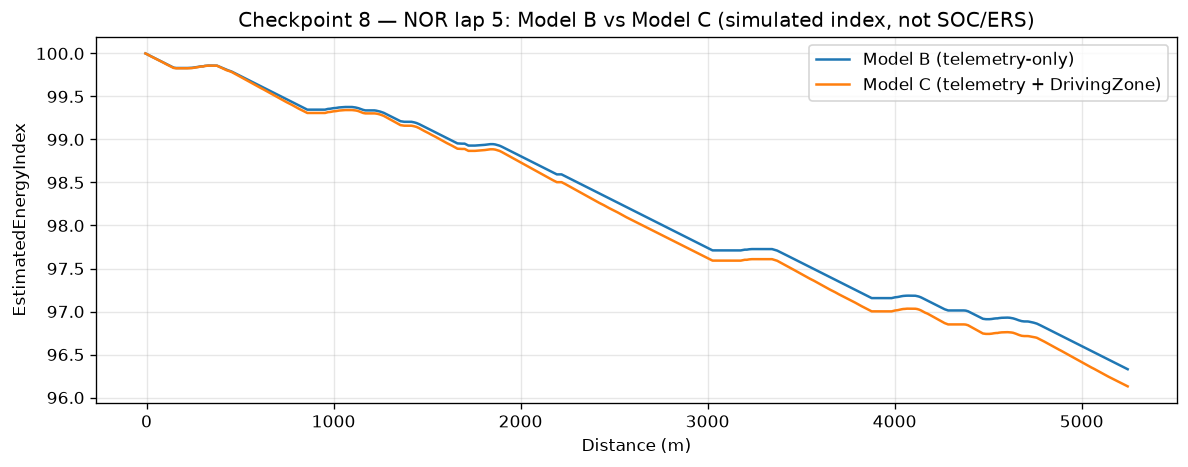

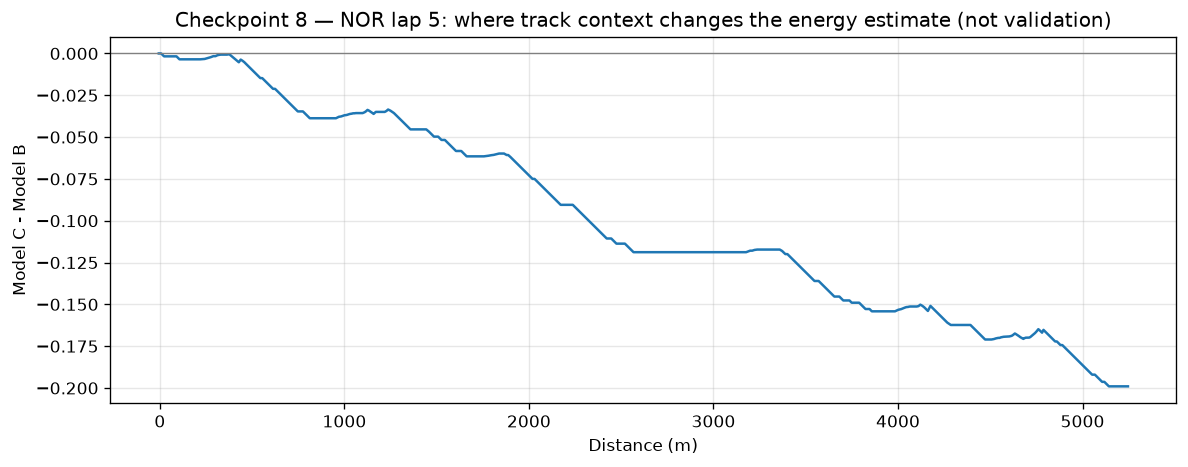

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import fastf1

fastf1.Cache.enable_cache("../cache")
session = fastf1.get_session(2026, "Australian Grand Prix", "R")
session.load()

clean_path = os.path.join("..", "data", "processed", "australian_gp_2026_laps_clean.csv")
laps_clean = pd.read_csv(clean_path)

preferred = laps_clean[
    (laps_clean["Driver"] == "NOR")
    & (laps_clean["LapNumber"] == 5)
    & (laps_clean["IsAccurate"] == True)
    & laps_clean["PitInTime"].isna()
    & laps_clean["PitOutTime"].isna()
    & (laps_clean["TrackStatus"].astype(str) == "1")
]
ref_row = preferred.iloc[0]

print("=" * 70)
print("CHECKPOINT 8 — TRACK-AWARE ENERGY MODEL COMPARISON")
print("=" * 70)
print("Experimental comparison only. No ground-truth SOC/ERS. Not a validation.")
print("Driver:", ref_row["Driver"])
print("LapNumber:", ref_row["LapNumber"])

lap = session.laps.pick_drivers(str(ref_row["Driver"])).pick_laps(int(ref_row["LapNumber"])).iloc[0]
car_data = lap.get_car_data(pad=1, pad_side="both").add_distance()
tel = car_data.copy()

tel["DeltaTimeSeconds"] = tel["Date"].diff().dt.total_seconds()
tel["SpeedMS"] = tel["Speed"] / 3.6
valid_dt = np.isfinite(tel["DeltaTimeSeconds"]) & (tel["DeltaTimeSeconds"] > 0)
tel["AccelerationMS2"] = tel["SpeedMS"].diff() / tel["DeltaTimeSeconds"]
tel.loc[~valid_dt, "AccelerationMS2"] = np.nan
tel["DecelerationMS2"] = np.where(
    tel["AccelerationMS2"].isna(),
    np.nan,
    np.where(tel["AccelerationMS2"] < 0, -tel["AccelerationMS2"], 0.0),
)

max_speed = float(tel["Speed"].max())
tel["DeployProxy"] = (tel["Speed"] / max_speed) * (tel["Throttle"] / 100.0)
DECELERATION_THRESHOLD = 5.0
tel["HarvestActive"] = (tel["Brake"] == True) & (tel["DecelerationMS2"] >= DECELERATION_THRESHOLD)
active_decel = tel.loc[tel["HarvestActive"], "DecelerationMS2"]
max_active_decel = float(active_decel.max()) if len(active_decel) else np.nan
tel["HarvestProxy"] = 0.0
if np.isfinite(max_active_decel) and max_active_decel > 0:
    tel.loc[tel["HarvestActive"], "HarvestProxy"] = (
        (tel.loc[tel["HarvestActive"], "Speed"] / max_speed)
        * (tel.loc[tel["HarvestActive"], "DecelerationMS2"] / max_active_decel)
    )

CORNER_RADIUS_METERS = 150
corners = session.get_circuit_info().corners
corner_dist = corners["Distance"].to_numpy(dtype=float)
corner_num = corners["Number"].to_numpy()
abs_diff = np.abs(tel["Distance"].to_numpy(dtype=float)[:, None] - corner_dist)
nearest_i = abs_diff.argmin(axis=1)
tel["NearestCorner"] = corner_num[nearest_i]
tel["DistanceToNearestCorner"] = abs_diff[np.arange(len(tel)), nearest_i]
tel["TrackContext"] = np.where(
    tel["DistanceToNearestCorner"] <= CORNER_RADIUS_METERS,
    "CORNER_REGION",
    "STRAIGHT",
)

BRAKING_DECEL_THRESHOLD = 5.0
ACCELERATION_THRESHOLD = 2.0
LOW_SPEED_THRESHOLD = 180.0
braking = (tel["Brake"] == True) & (tel["DecelerationMS2"] >= BRAKING_DECEL_THRESHOLD)
accel_zone = (
    (~braking)
    & (tel["AccelerationMS2"] >= ACCELERATION_THRESHOLD)
    & (tel["Throttle"] >= 50)
)
low_speed = (
    (~braking)
    & (~accel_zone)
    & (tel["Speed"] <= LOW_SPEED_THRESHOLD)
    & (tel["TrackContext"] == "CORNER_REGION")
)
tel["DrivingZone"] = "CRUISE"
tel.loc[low_speed, "DrivingZone"] = "LOW_SPEED_CORNER"
tel.loc[accel_zone, "DrivingZone"] = "ACCELERATION"
tel.loc[braking, "DrivingZone"] = "BRAKING"

INITIAL_ENERGY = 100.0
DEPLOY_RATE = 0.10
HARVEST_RATE = 0.05
print("\nRATES UNCHANGED FROM CHECKPOINT 5 (modeling parameters, not F1)")
print("DEPLOY_RATE:", DEPLOY_RATE)
print("HARVEST_RATE:", HARVEST_RATE)

dt = tel["DeltaTimeSeconds"].copy()
dt = dt.where(np.isfinite(dt) & (dt > 0), 0.0)


def walk_energy(used, recovered, initial=INITIAL_ENERGY):
    n = len(used)
    energy = np.empty(n, dtype=float)
    raw_state = np.empty(n, dtype=float)
    energy[0] = initial
    raw_state[0] = initial
    for i in range(1, n):
        raw = energy[i - 1] - used.iloc[i] + recovered.iloc[i]
        raw_state[i] = raw
        energy[i] = min(100.0, max(0.0, raw))
    return energy, raw_state


# --- MODEL B (telemetry-only, Checkpoint 5) ---
tel["EnergyUsed_B"] = tel["DeployProxy"].fillna(0.0) * DEPLOY_RATE * dt
tel["EnergyRecovered_B"] = tel["HarvestProxy"].fillna(0.0) * HARVEST_RATE * dt
energy_b, raw_b = walk_energy(tel["EnergyUsed_B"], tel["EnergyRecovered_B"])
tel["EstimatedEnergyIndex_B"] = energy_b

# --- MODEL C (same proxies + DrivingZone multipliers) ---
print("\nMODEL C CONTEXT MULTIPLIERS (modeling choices, not F1 measurements)")
print("DeploymentContextMultiplier: ACCELERATION=1.10, CRUISE=1.00, LOW_SPEED_CORNER=0.80, BRAKING=0.00")
print("HarvestContextMultiplier:    BRAKING=1.10, LOW_SPEED_CORNER=0.50, ACCELERATION=0.00, CRUISE=0.00")
print("Why: acceleration is stronger deployment; low-speed corners have lower propulsion demand;")
print("braking is the strongest recovery context; acceleration/cruise are not treated as recovery.")

deploy_mult = {
    "ACCELERATION": 1.10,
    "CRUISE": 1.00,
    "LOW_SPEED_CORNER": 0.80,
    "BRAKING": 0.00,
}
harvest_mult = {
    "BRAKING": 1.10,
    "LOW_SPEED_CORNER": 0.50,
    "ACCELERATION": 0.00,
    "CRUISE": 0.00,
}
tel["DeploymentContextMultiplier"] = tel["DrivingZone"].map(deploy_mult).astype(float)
tel["HarvestContextMultiplier"] = tel["DrivingZone"].map(harvest_mult).astype(float)
tel["DeployProxy_C"] = tel["DeployProxy"] * tel["DeploymentContextMultiplier"]
tel["HarvestProxy_C"] = tel["HarvestProxy"] * tel["HarvestContextMultiplier"]

tel["EnergyUsed_C"] = tel["DeployProxy_C"].fillna(0.0) * DEPLOY_RATE * dt
tel["EnergyRecovered_C"] = tel["HarvestProxy_C"].fillna(0.0) * HARVEST_RATE * dt
energy_c, raw_c = walk_energy(tel["EnergyUsed_C"], tel["EnergyRecovered_C"])
tel["EstimatedEnergyIndex_C"] = energy_c

# --- STEP 6 comparison ---
print("\n" + "=" * 70)
print("STEP 6 — MODEL COMPARISON")
print("=" * 70)
print("\nMODEL B")
print("total EnergyUsed:", float(tel["EnergyUsed_B"].sum()))
print("total EnergyRecovered:", float(tel["EnergyRecovered_B"].sum()))
print("final EnergyIndex:", float(tel["EstimatedEnergyIndex_B"].iloc[-1]))
print("minimum EnergyIndex:", float(tel["EstimatedEnergyIndex_B"].min()))
print("maximum EnergyIndex:", float(tel["EstimatedEnergyIndex_B"].max()))

print("\nMODEL C")
print("total EnergyUsed:", float(tel["EnergyUsed_C"].sum()))
print("total EnergyRecovered:", float(tel["EnergyRecovered_C"].sum()))
print("final EnergyIndex:", float(tel["EstimatedEnergyIndex_C"].iloc[-1]))
print("minimum EnergyIndex:", float(tel["EstimatedEnergyIndex_C"].min()))
print("maximum EnergyIndex:", float(tel["EstimatedEnergyIndex_C"].max()))

final_diff = float(tel["EstimatedEnergyIndex_C"].iloc[-1] - tel["EstimatedEnergyIndex_B"].iloc[-1])
mae = float((tel["EstimatedEnergyIndex_C"] - tel["EstimatedEnergyIndex_B"]).abs().mean())
print("\nFinalEnergyDifference (C_final - B_final):", final_diff)
print("MeanAbsoluteEnergyDifference:", mae)
print("max |C - B| along the lap:", float((tel["EstimatedEnergyIndex_C"] - tel["EstimatedEnergyIndex_B"]).abs().max()))

# --- STEP 7: did track context change the model? ---
print("\n" + "=" * 70)
print("STEP 7 — DOES TRACK CONTEXT CHANGE THE PROXIES?")
print("=" * 70)
deploy_changed = tel["DeployProxy_C"] != tel["DeployProxy"]
harvest_changed = tel["HarvestProxy_C"] != tel["HarvestProxy"]
either_changed = deploy_changed | harvest_changed
print("n DeployProxy_C != DeployProxy:", int(deploy_changed.sum()))
print("n HarvestProxy_C != HarvestProxy:", int(harvest_changed.sum()))
print("n samples with either proxy changed:", int(either_changed.sum()))
print("percentage of samples affected (either proxy):", round(100.0 * float(either_changed.mean()), 2))
print("total change in modeled deployment sum(EnergyUsed_C - EnergyUsed_B):", float((tel["EnergyUsed_C"] - tel["EnergyUsed_B"]).sum()))
print("total change in modeled recovery sum(EnergyRecovered_C - EnergyRecovered_B):", float((tel["EnergyRecovered_C"] - tel["EnergyRecovered_B"]).sum()))
print("sum(DeployProxy_C - DeployProxy):", float((tel["DeployProxy_C"] - tel["DeployProxy"]).sum()))
print("sum(HarvestProxy_C - HarvestProxy):", float((tel["HarvestProxy_C"] - tel["HarvestProxy"]).sum()))

zone_proxy = tel.groupby("DrivingZone").agg(
    sample_count=("DrivingZone", "size"),
    mean_DeployProxy=("DeployProxy", "mean"),
    mean_DeployProxy_C=("DeployProxy_C", "mean"),
    mean_HarvestProxy=("HarvestProxy", "mean"),
    mean_HarvestProxy_C=("HarvestProxy_C", "mean"),
)
print("\nPROXY MEANS BY DrivingZone")
print(zone_proxy.to_string())

# --- STEP 8: unintended behaviour ---
print("\n" + "=" * 70)
print("STEP 8 — UNINTENDED-BEHAVIOUR CHECKS (report, do not silently fix)")
print("=" * 70)

braking_mask = tel["DrivingZone"] == "BRAKING"
accel_mask = tel["DrivingZone"] == "ACCELERATION"
low_mask = tel["DrivingZone"] == "LOW_SPEED_CORNER"
cruise_mask = tel["DrivingZone"] == "CRUISE"

print("\n1. Does Model C increase energy demand during braking?")
print("   mean EnergyUsed_B in BRAKING:", float(tel.loc[braking_mask, "EnergyUsed_B"].mean()))
print("   mean EnergyUsed_C in BRAKING:", float(tel.loc[braking_mask, "EnergyUsed_C"].mean()))
print("   n BRAKING samples with EnergyUsed_C > EnergyUsed_B:", int(((braking_mask) & (tel["EnergyUsed_C"] > tel["EnergyUsed_B"])).sum()))

print("\n2. Does Model C create harvesting during acceleration?")
print("   mean HarvestProxy in ACCELERATION:", float(tel.loc[accel_mask, "HarvestProxy"].mean()))
print("   mean HarvestProxy_C in ACCELERATION:", float(tel.loc[accel_mask, "HarvestProxy_C"].mean()))
print("   n ACCELERATION samples with HarvestProxy_C > 0:", int(((accel_mask) & (tel["HarvestProxy_C"] > 0)).sum()))

print("\n3. Does Model C increase deployment in low-speed corners?")
print("   mean EnergyUsed_B in LOW_SPEED_CORNER:", float(tel.loc[low_mask, "EnergyUsed_B"].mean()))
print("   mean EnergyUsed_C in LOW_SPEED_CORNER:", float(tel.loc[low_mask, "EnergyUsed_C"].mean()))
print("   n LOW_SPEED_CORNER samples with EnergyUsed_C > EnergyUsed_B:", int(((low_mask) & (tel["EnergyUsed_C"] > tel["EnergyUsed_B"])).sum()))

print("\n4. Does Model C make recovery occur outside braking?")
outside_braking = ~braking_mask
print("   n non-BRAKING samples with HarvestProxy > 0:", int((outside_braking & (tel["HarvestProxy"] > 0)).sum()))
print("   n non-BRAKING samples with HarvestProxy_C > 0:", int((outside_braking & (tel["HarvestProxy_C"] > 0)).sum()))
print("   total EnergyRecovered_C outside BRAKING:", float(tel.loc[outside_braking, "EnergyRecovered_C"].sum()))

print("\n5. Does the energy state remain bounded?")
print("   Model B min/max:", float(tel["EstimatedEnergyIndex_B"].min()), float(tel["EstimatedEnergyIndex_B"].max()))
print("   Model C min/max:", float(tel["EstimatedEnergyIndex_C"].min()), float(tel["EstimatedEnergyIndex_C"].max()))
print("   n Model C raw state < 0:", int((raw_c[1:] < 0).sum()))
print("   n Model C raw state > 100:", int((raw_c[1:] > 100).sum()))
print("   n Model C at 0:", int((tel["EstimatedEnergyIndex_C"] == 0).sum()))
print("   n Model C at 100:", int((tel["EstimatedEnergyIndex_C"] == 100).sum()))

print("\n6. Does Model C produce extreme changes vs Model B?")
rel_used = float(tel["EnergyUsed_C"].sum() / tel["EnergyUsed_B"].sum()) if tel["EnergyUsed_B"].sum() else np.nan
rel_rec = float(tel["EnergyRecovered_C"].sum() / tel["EnergyRecovered_B"].sum()) if tel["EnergyRecovered_B"].sum() else np.nan
print("   EnergyUsed_C / EnergyUsed_B:", rel_used)
print("   EnergyRecovered_C / EnergyRecovered_B:", rel_rec)
print("   FinalEnergyDifference:", final_diff)
print("   MeanAbsoluteEnergyDifference:", mae)
print("   This is a small adjustment by construction; extreme would mean large rate-like jumps or leaving [0, 100].")

print("\nNOTE: HarvestProxy is already gated to Brake AND Decel>=5, which is the same rule as DrivingZone=BRAKING.")
print("So HarvestContextMultiplier on ACCELERATION/CRUISE/LOW_SPEED_CORNER has no effect unless HarvestProxy is already non-zero.")

print("\nFIRST 8 ROWS (comparison)")
print(
    tel.loc[
        :,
        [
            "Distance",
            "DrivingZone",
            "DeployProxy",
            "DeployProxy_C",
            "HarvestProxy",
            "HarvestProxy_C",
            "EnergyUsed_B",
            "EnergyUsed_C",
            "EnergyRecovered_B",
            "EnergyRecovered_C",
            "EstimatedEnergyIndex_B",
            "EstimatedEnergyIndex_C",
        ],
    ]
    .head(8)
    .to_string()
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(tel["Distance"], tel["EstimatedEnergyIndex_B"], label="Model B (telemetry-only)")
ax.plot(tel["Distance"], tel["EstimatedEnergyIndex_C"], label="Model C (telemetry + DrivingZone)")
ax.set_xlabel("Distance (m)")
ax.set_ylabel("EstimatedEnergyIndex")
ax.set_title("Checkpoint 8 — NOR lap 5: Model B vs Model C (simulated index, not SOC/ERS)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(tel["Distance"], tel["EstimatedEnergyIndex_C"] - tel["EstimatedEnergyIndex_B"])
ax.axhline(0.0, color="gray", linewidth=0.8)
ax.set_xlabel("Distance (m)")
ax.set_ylabel("Model C - Model B")
ax.set_title("Checkpoint 8 — NOR lap 5: where track context changes the energy estimate (not validation)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
